In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
header = ["x", "y", "z"]
chunk_size = 500
filename = "pos/0.csv"

In [10]:
def process_pos(filename):
    df = pd.read_csv(filename, names=header, header=None)
    df["mod"] = (df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2) ** (1 / 2)
    return df
def split_chunks(df,chunk_size):
    chunks = [v for k, v in df.groupby(np.arange(len(df)) // chunk_size)]
    return chunks
def calculate_histogram(df, column_name="mod", num_bins=50):

    # Define fixed bins based on the total min/max of the data
    # This ensures every chunk's histogram aligns correctly
    data_min, data_max = df[column_name].min(), df[column_name].max()
    bins = np.linspace(data_min, data_max, num_bins + 1)

    # 2. Initialize the accumulated histogram
    accum = np.zeros(num_bins)

    # 3. Iterate through chunks
    for iteration in range(0, len(df) // chunk_size + 1):
        # Get the chunk
        start = iteration * chunk_size
        end = start + chunk_size
        chunk = df[column_name].iloc[start:end]

        if chunk.empty:
            continue

        # Calculate histogram for the current chunk
        # np.histogram returns (counts, bin_edges); we only need counts [0]
        histo, _ = np.histogram(chunk, bins=bins)

        # 4. Apply your formula:
        # accum[i] = (iteration * accum[i] + histo[i]) / (iteration + 1)
        accum = (iteration * accum + histo) / (iteration + 1)
    return accum,bins

def plot_hist(accum,bins):
    plt.bar(bins[:-1], accum, width=np.diff(bins), edgecolor="black", align="edge")
    plt.title("Histograma acumulat")
    plt.xlabel("Posició Z")
    plt.ylabel("Nº Atoms")

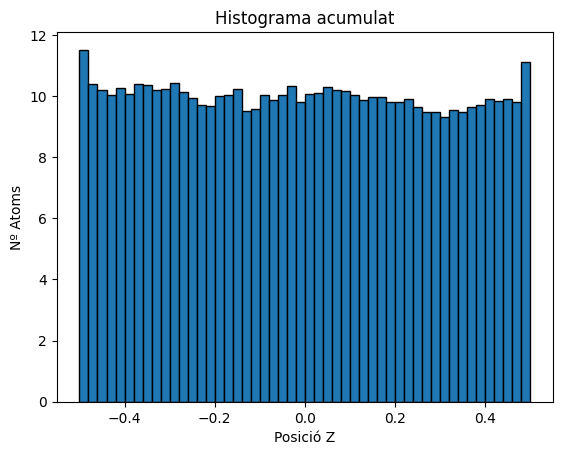

In [11]:
df = process_pos(filename)
accum,bins = calculate_histogram(df,"z")
plot_hist(accum,bins)

pos\0_05.csv


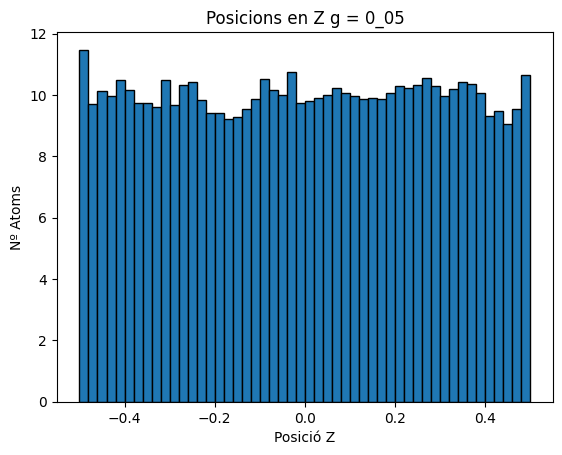

pos\0_06.csv


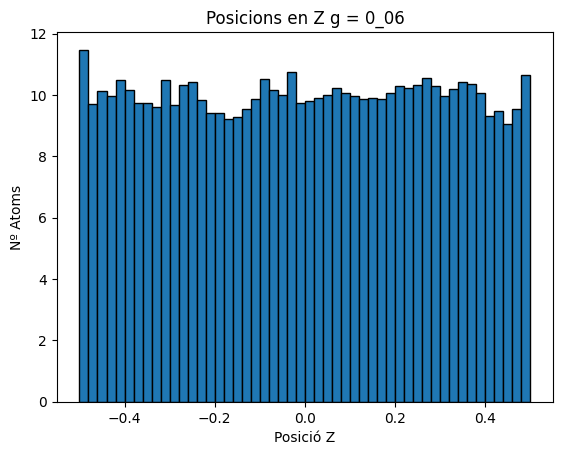

pos\0_1.csv


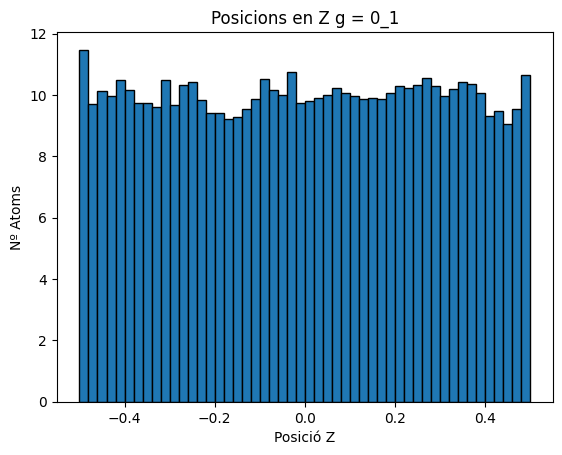

pos\0_2.csv


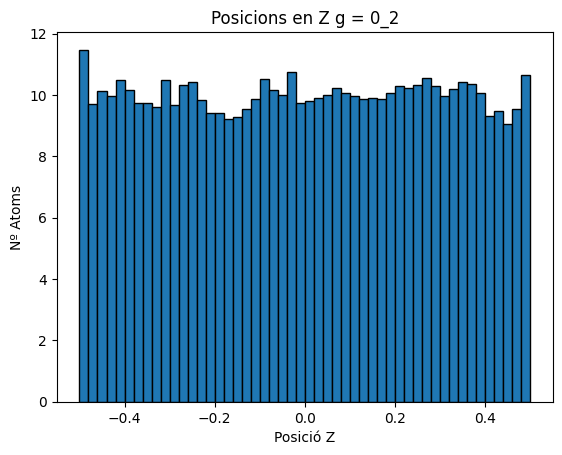

pos\0_5.csv


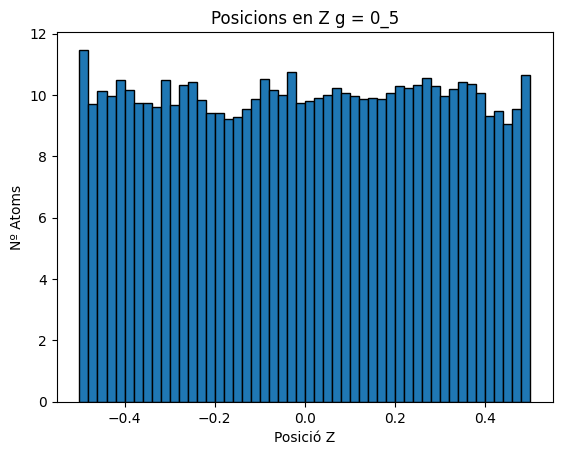

In [29]:
folder_path = Path('pos')
for file_path in folder_path.glob('0_*.csv'):
    print(file_path)
    accum,bins = calculate_histogram(df,"x")
    plot_hist(accum,bins)
    if file_path.name == "0.csv":
        plt.title("Posicions en Z sense gravetat")
    else:
        plt.title(f"Posicions en Z g = {file_path.name[:-4]}")
    plt.show()

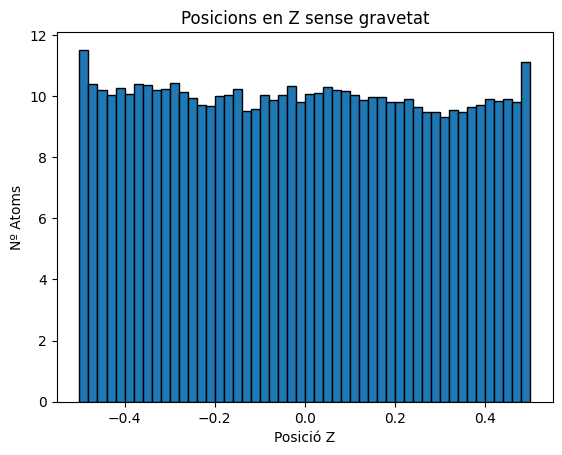

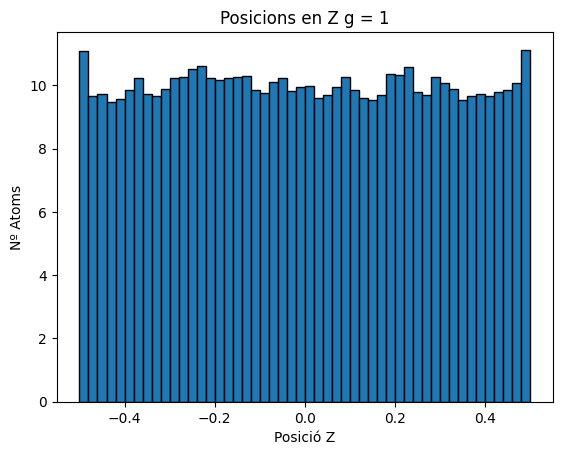

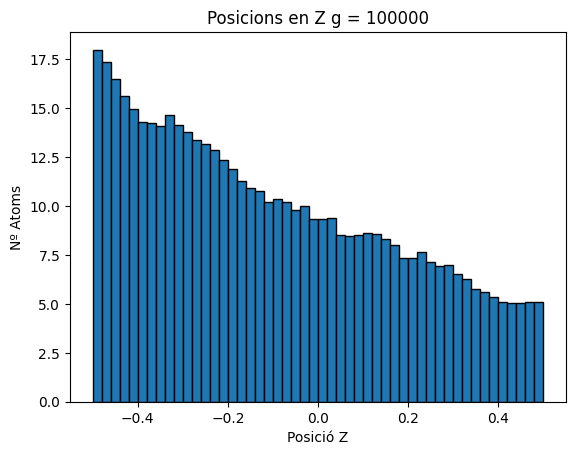

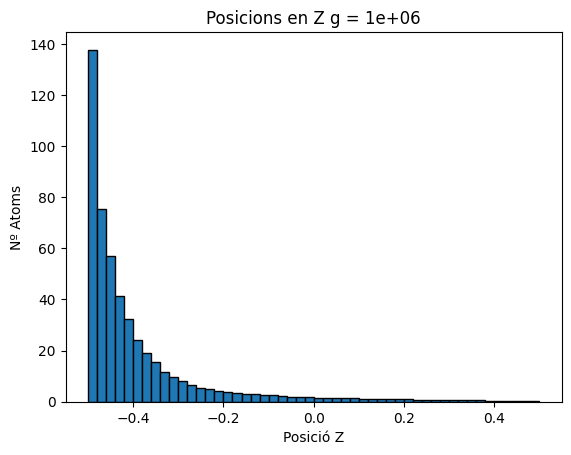

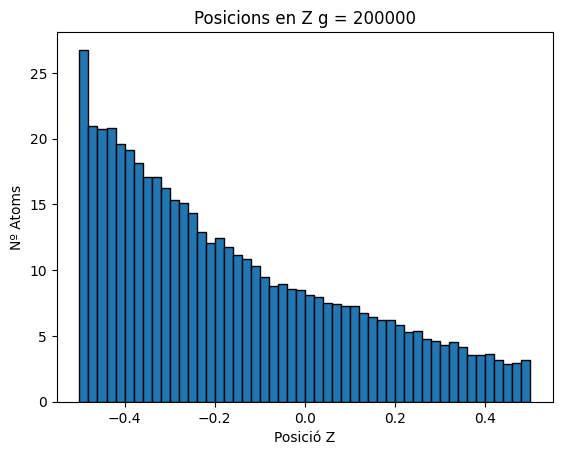

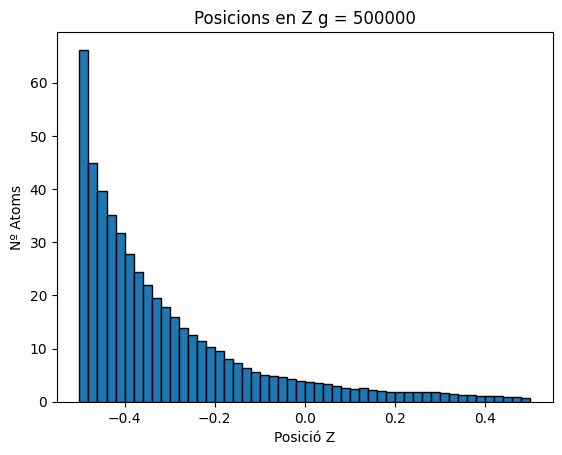

In [16]:
folder_path = Path('pos')
for file_path in folder_path.glob('*.csv'):
    if file_path.name in ["1e+07.csv","5e+06.csv","2e+06.csv"]:
        continue
    df = process_pos(file_path)
    accum,bins = calculate_histogram(df,"z")
    plot_hist(accum,bins)
    if file_path.name == "0.csv":
        plt.title("Posicions en Z sense gravetat")
    else:
        plt.title(f"Posicions en Z g = {file_path.name[:-4]}")
    plt.savefig(f"imatges/{file_path.name[:-4]}")
    plt.show()
    